In [1]:
# Set working directory at the root level, run ONCE
import os
from pathlib import Path

os.chdir(Path().resolve().parent)
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\bonia\YEAR4\CPSC440\vae-lidar


Points in scan: 122695
x range: -79.8 to 78.6 m
y range: -74.9 to 78.9 m
z range: -3.1 to 2.9 m


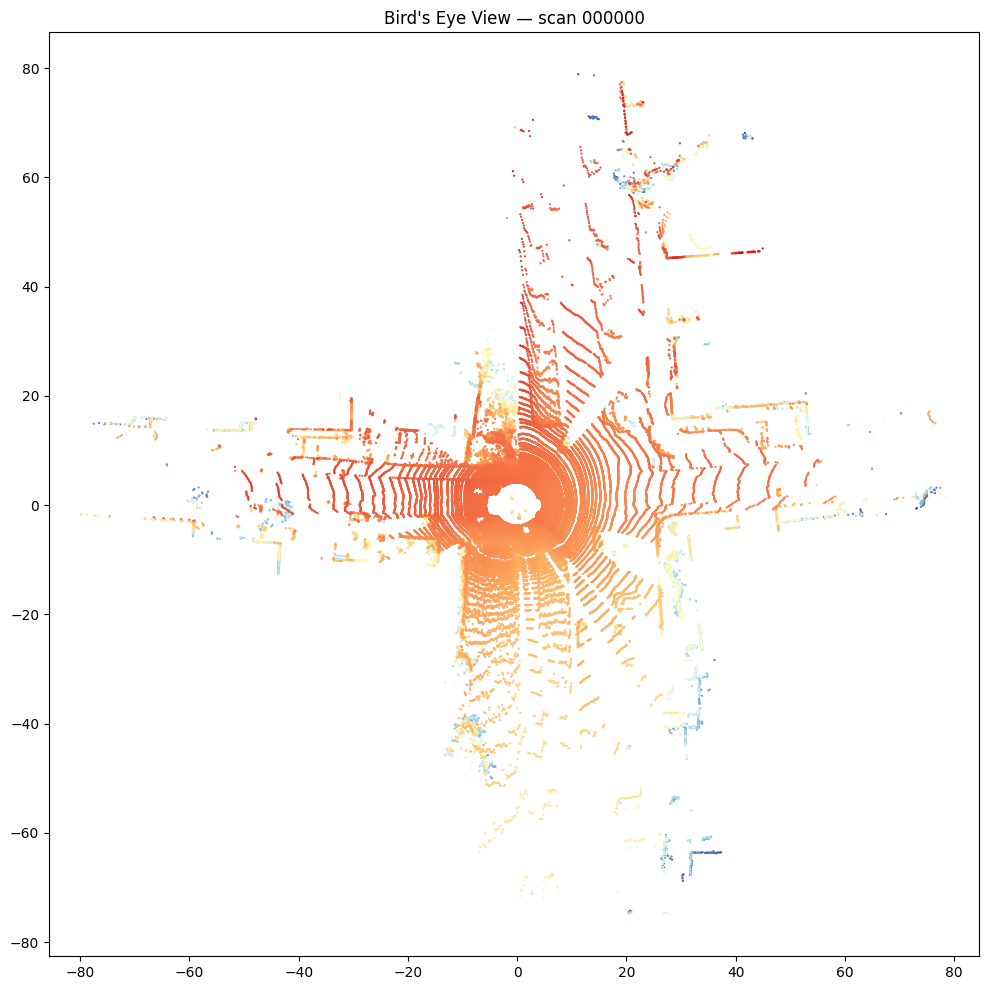

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Each .bin file is a flat array of (x, y, z, intensity) floats
scan = np.fromfile('./data/kitti/data_object_velodyne/training/velodyne/001000.bin', dtype=np.float32)
scan = scan.reshape(-1, 4)   # shape: (N, 4) — typically ~120,000 points

print(f"Points in scan: {len(scan)}")
print(f"x range: {scan[:,0].min():.1f} to {scan[:,0].max():.1f} m")
print(f"y range: {scan[:,1].min():.1f} to {scan[:,1].max():.1f} m")
print(f"z range: {scan[:,2].min():.1f} to {scan[:,2].max():.1f} m")

# Quick BEV scatter plot to see the scene
plt.figure(figsize=(12, 12))
plt.scatter(scan[:,0], scan[:,1], s=0.3, c=scan[:,2], cmap='RdYlBu')
plt.axis('equal')
plt.title('Bird\'s Eye View — scan 000000')
plt.show()

In [3]:
from src.dataset import load_kitti_bin

bev = load_kitti_bin("./data/kitti/data_object_velodyne/training/velodyne/001000.bin")
print(bev)

[[[0.75 0.75 0.75 ... 0.75 0.75 0.75]
  [0.75 0.75 0.75 ... 0.75 0.75 0.75]
  [0.75 0.75 0.75 ... 0.75 0.75 0.75]
  ...
  [0.75 0.75 0.75 ... 0.75 0.75 0.75]
  [0.75 0.75 0.75 ... 0.75 0.75 0.75]
  [0.75 0.75 0.75 ... 0.75 0.75 0.75]]

 [[0.   0.   0.   ... 0.   0.   0.  ]
  [0.   0.   0.   ... 0.   0.   0.  ]
  [0.   0.   0.   ... 0.   0.   0.  ]
  ...
  [0.   0.   0.   ... 0.   0.   0.  ]
  [0.   0.   0.   ... 0.   0.   0.  ]
  [0.   0.   0.   ... 0.   0.   0.  ]]

 [[0.   0.   0.   ... 0.   0.   0.  ]
  [0.   0.   0.   ... 0.   0.   0.  ]
  [0.   0.   0.   ... 0.   0.   0.  ]
  ...
  [0.   0.   0.   ... 0.   0.   0.  ]
  [0.   0.   0.   ... 0.   0.   0.  ]
  [0.   0.   0.   ... 0.   0.   0.  ]]]


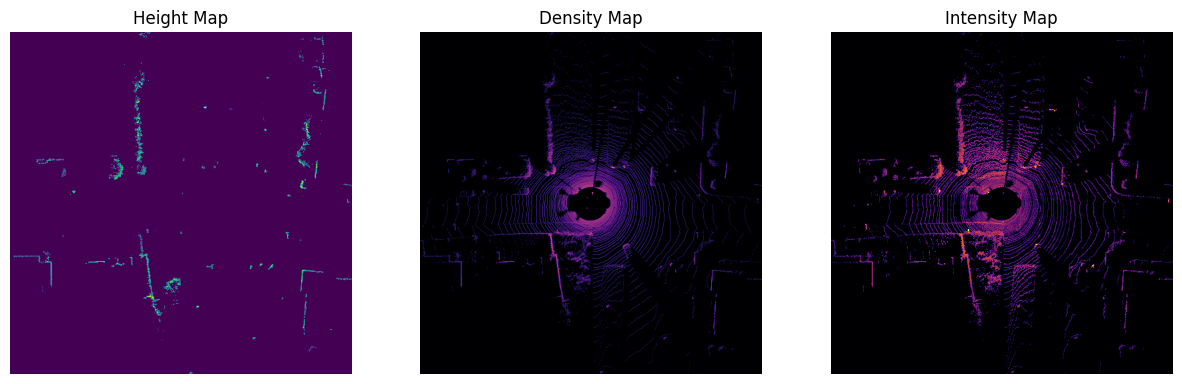

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(bev[0], cmap="viridis")
axes[0].set_title("Height Map")

axes[1].imshow(bev[1], cmap="magma")
axes[1].set_title("Density Map")

axes[2].imshow(bev[2], cmap="inferno")
axes[2].set_title("Intensity Map")

for ax in axes:
    ax.axis("off")

plt.show()

In [5]:
# DataLoader iterates a full batch correctly?
from torch.utils.data import DataLoader
from src.dataset import KITTIBEVDataset

dataset = KITTIBEVDataset(scan_dir=
    "./data/kitti/data_object_velodyne/training/velodyne"
)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(loader))

print(type(batch))
print(batch.shape)

<class 'torch.Tensor'>
torch.Size([4, 3, 512, 512])


In [6]:
from src.model import VAE

model = VAE()
recon, mu, logvar = model(batch)

print(recon.shape)  # expect (2, 3, 512, 512)

torch.Size([4, 3, 512, 512])


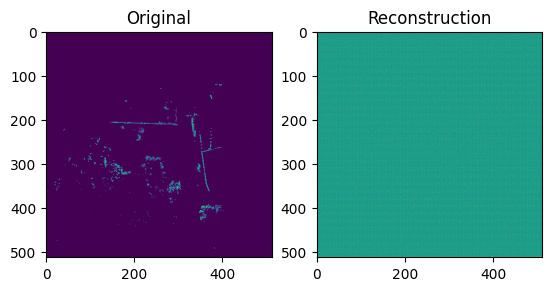

In [7]:
import matplotlib.pyplot as plt

x = batch[0].numpy()
r = recon[0].detach().numpy()

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(x[0])

plt.subplot(1,2,2)
plt.title("Reconstruction")
plt.imshow(r[0])

plt.show()

In [33]:
import importlib
import src.train

importlib.reload(src.train)
from src.train import train

train(resume_from='outputs/bce_loss/vae_bce_epoch30.pt')

Training on: cuda
Resumed from outputs/bce_loss/vae_bce_epoch30.pt, starting at epoch 31
Epoch 031 | β=0.10 | Train: 181665.85 | Val: 181762.48 | Recon: 180867.72 | KL: 913.70
Epoch 032 | β=0.10 | Train: 181500.95 | Val: 181819.72 | Recon: 179360.30 | KL: 889.70
Epoch 033 | β=0.10 | Train: 181418.26 | Val: 181906.55 | Recon: 179793.48 | KL: 868.61
Epoch 034 | β=0.10 | Train: 181343.12 | Val: 181984.86 | Recon: 183084.25 | KL: 1070.85
Epoch 035 | β=0.10 | Train: 181255.57 | Val: 182029.53 | Recon: 187524.19 | KL: 883.96
Epoch 036 | β=0.10 | Train: 181195.47 | Val: 182085.02 | Recon: 177430.95 | KL: 1068.12
Epoch 037 | β=0.10 | Train: 181108.36 | Val: 182120.82 | Recon: 184631.17 | KL: 876.13
Epoch 038 | β=0.10 | Train: 181045.04 | Val: 182199.63 | Recon: 176941.03 | KL: 966.46
Epoch 039 | β=0.10 | Train: 180976.62 | Val: 182255.27 | Recon: 184838.03 | KL: 901.46
Epoch 040 | β=0.10 | Train: 180913.81 | Val: 182303.64 | Recon: 173843.73 | KL: 968.13
Epoch 041 | β=0.10 | Train: 180842.33 |

KeyboardInterrupt: 

C:\Users\bonia\AppData\Local\Temp\ipykernel_23240\4143182752.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("outputs/vae_epoch100.pt"))

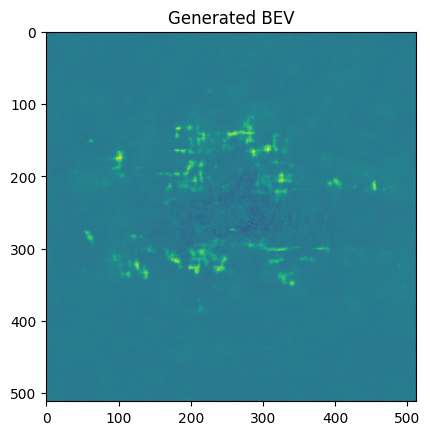

In [18]:
import torch

model = VAE()
model.load_state_dict(torch.load("outputs/vae_epoch100.pt"))
model.eval()

samples = model.sample(4, device="cpu")

plt.imshow(samples[0][0].detach().numpy())
plt.title("Generated BEV")
plt.show()

C:\Users\bonia\AppData\Local\Temp\ipykernel_23240\1975185132.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('outputs/bce_loss/vae_bce_e

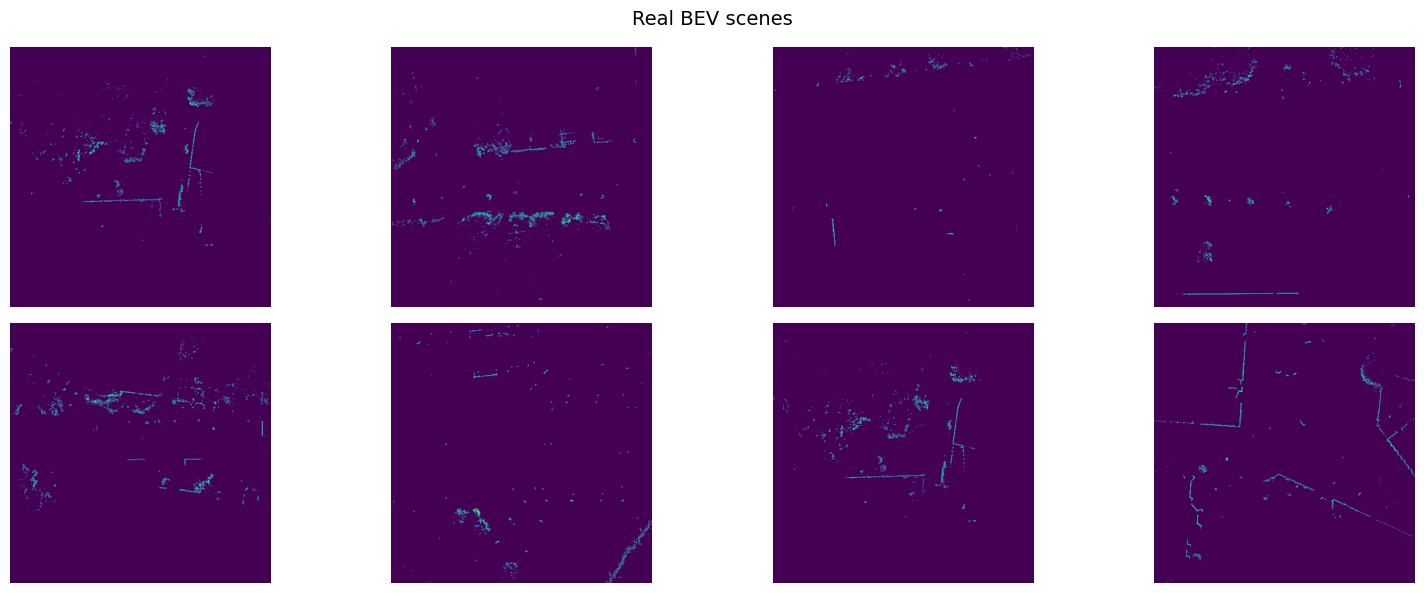

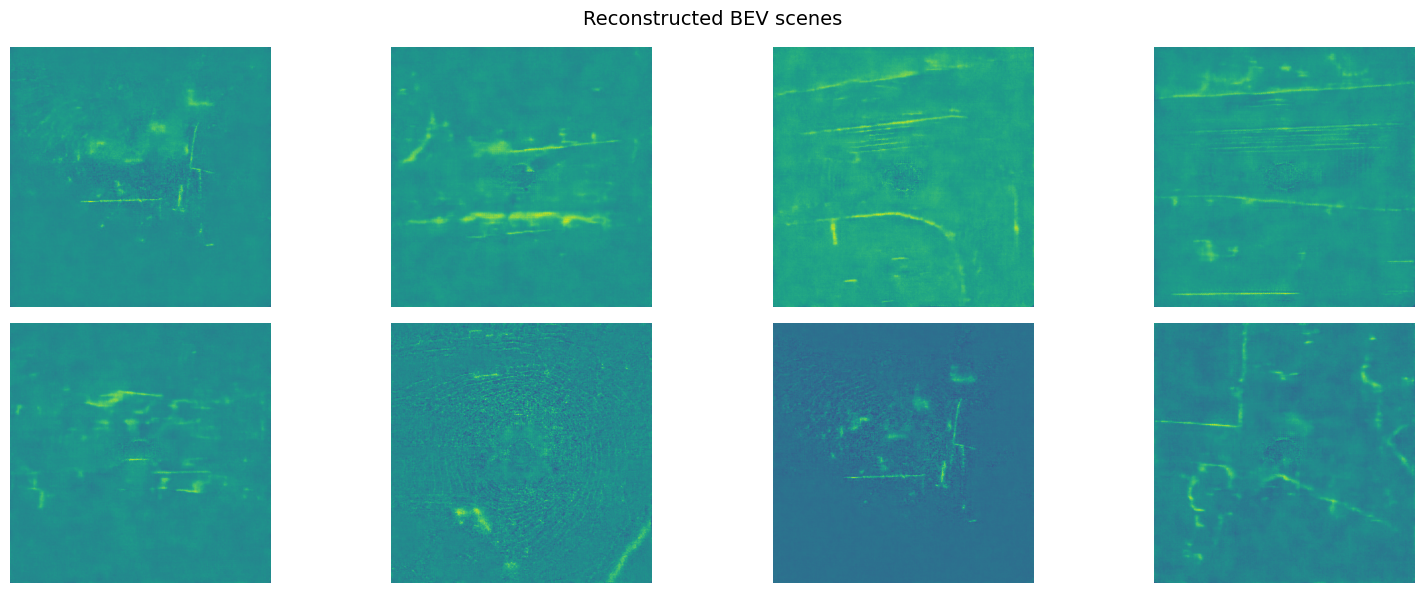

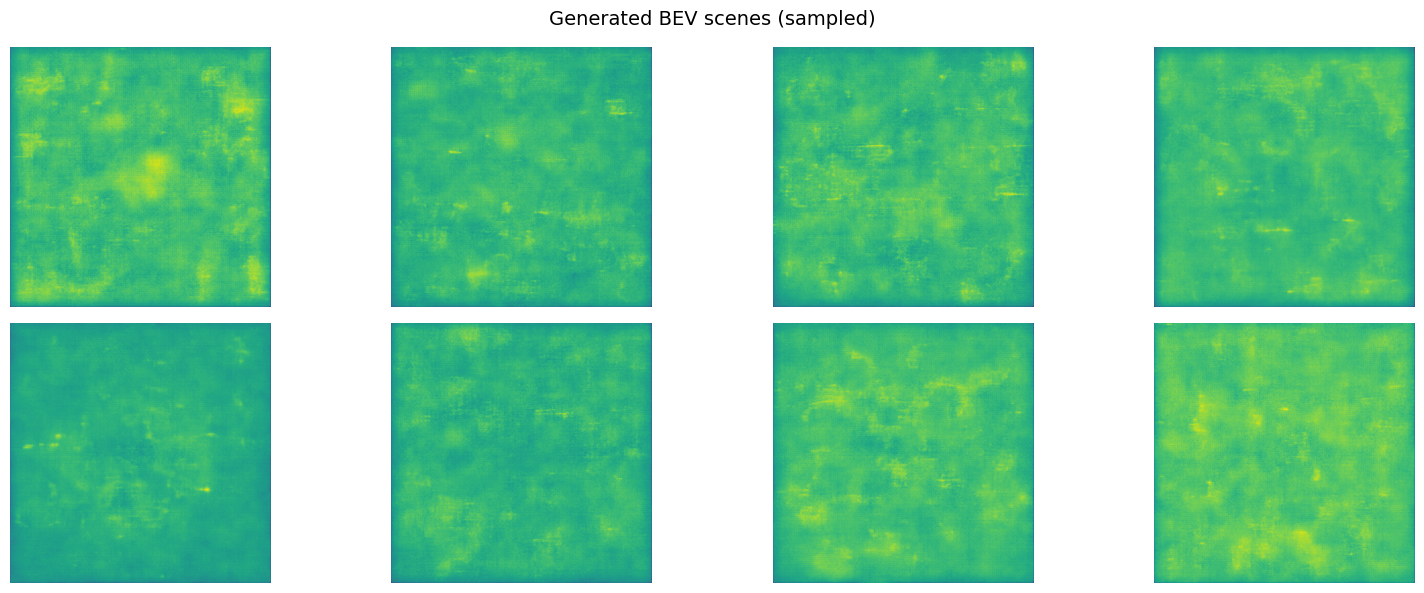

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model
model = VAE(latent_dim=256).to(device)
model.load_state_dict(torch.load('outputs/bce_loss/vae_bce_epoch60.pt', map_location=device))
model.eval()

# Load a few real samples
dataset = KITTIBEVDataset('data/kitti/data_object_velodyne/training/velodyne')
loader  = DataLoader(dataset, batch_size=8, shuffle=True)
real    = next(iter(loader)).to(device)

# Get reconstructions
with torch.no_grad():
    recon, mu, logvar = model(real)
    generated = model.sample(8, device)

def show_bev(tensor, title):
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    fig.suptitle(title, fontsize=14)
    for i, ax in enumerate(axes.flat):
        img = tensor[i, 0].cpu().numpy()
        # Remove vmin/vmax — let each image auto-scale to its own range
        ax.imshow(img, cmap='viridis', origin='lower')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'outputs/samples/{title.replace(" ", "_")}.png', dpi=100)
    plt.show()

show_bev(real,      "Real BEV scenes")
show_bev(recon,     "Reconstructed BEV scenes")
show_bev(generated, "Generated BEV scenes (sampled)")

In [25]:
with torch.no_grad():
    recon, mu, logvar = model(real)

print(f"Real    — min: {real.min():.4f}  max: {real.max():.4f}  mean: {real.mean():.4f}")
print(f"Recon   — min: {recon.min():.4f}  max: {recon.max():.4f}  mean: {recon.mean():.4f}")

Real    — min: 0.0000  max: 1.0000  mean: 0.2660
Recon   — min: 0.0000  max: 0.9272  mean: 0.2659


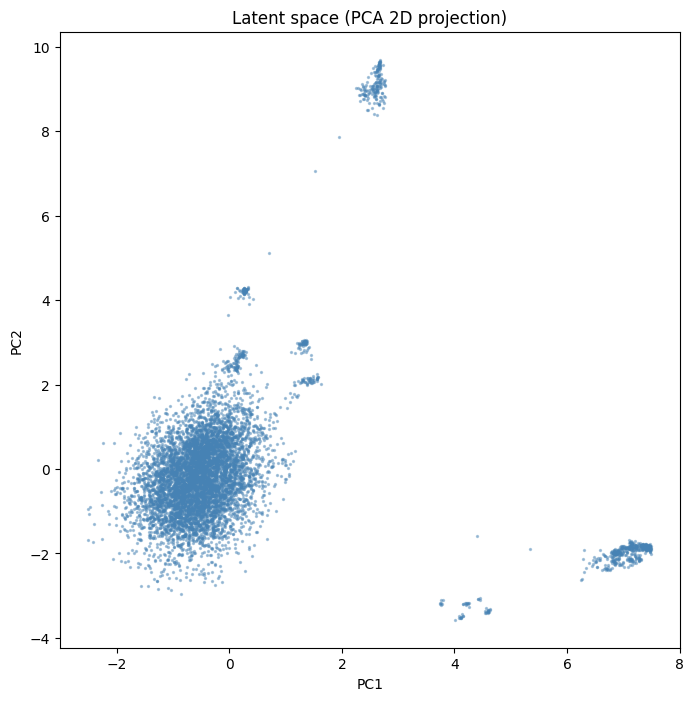

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Encode all training samples → collect latent vectors
all_mu = []
loader_full = DataLoader(dataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for batch in loader_full:
        mu, _ = model.encoder(batch.to(device))
        all_mu.append(mu.cpu().numpy())

all_mu = np.concatenate(all_mu, axis=0)

# PCA down to 2D for visualization
pca = PCA(n_components=2)
z_2d = pca.fit_transform(all_mu)

plt.figure(figsize=(8, 8))
plt.scatter(z_2d[:, 0], z_2d[:, 1], s=2, alpha=0.4, c='steelblue')
plt.title('Latent space (PCA 2D projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig('outputs/samples/latent_space.png', dpi=100)
plt.show()